In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import koreanize_matplotlib
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import seaborn as sns

df = pd.read_csv('house_price_train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [2]:
#버려, 결측치가 1400개 정도 됨, 의미 없음
df = df.drop(['PoolQC', 'MiscFeature', 'Alley'], axis=1)

In [3]:
#진짜 집에 없는 것들, None으로 처리
none_cols = [
    'Fence','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2', 'MasVnrType'
]

for col in none_cols:
    df[col] = df[col].fillna('None')

#데이터 자체가 비어있는 것 , 중앙값으로 처리 
num_cols = ['LotFrontage','MasVnrArea','GarageYrBlt']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#하나 비어있는것, 최빈값으로 처리 
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [4]:
# 원-핫 인코딩 (우선은 특성공학X)

# 등급별 매핑
qual_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

qual_cols = [
    'ExterQual','ExterCond','BsmtQual','BsmtCond',
    'HeatingQC','KitchenQual','FireplaceQu',
    'GarageQual','GarageCond'
]

df[qual_cols] = df[qual_cols].fillna('None')
df['BsmtExposure'] = df['BsmtExposure'].fillna('None')
df['GarageFinish'] = df['GarageFinish'].fillna('None')

for col in qual_cols:
    df[col] = df[col].map(qual_map)



# 기타 매핑
exposure_map = {
    'None': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

df['BsmtExposure'] = df['BsmtExposure'].map(exposure_map)

garage_map = {
    'None': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

df['GarageFinish'] = df['GarageFinish'].map(garage_map)


#원핫인코딩
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

cat_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(X.shape)
print(X.info()) 

(1460, 218)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 218 entries, Id to SaleCondition_Partial
dtypes: bool(170), float64(3), int64(45)
memory usage: 790.0 KB
None


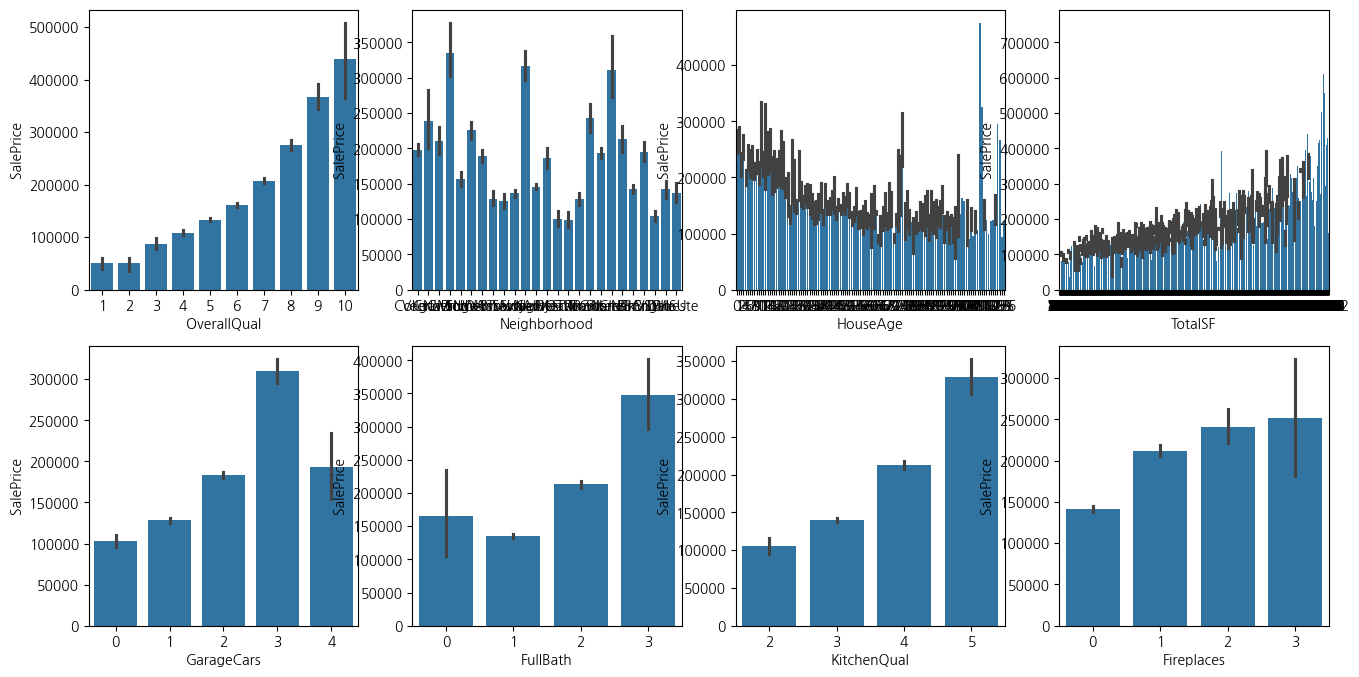

In [5]:
#시각화 

df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)
cat_features = [
    'OverallQual',     # 집 품질 
    'Neighborhood',    # 동네 
    'HouseAge',        # 집 나이 
    'TotalSF',         # 총 면적 
    'GarageCars',      # 주차 가능 대수
    'FullBath',        # 욕실 개수
    'KitchenQual',     # 주방 품질
    'Fireplaces'       # 벽난로 개수
]

for i, feature in enumerate(cat_features):
    row = int(i/4)
    col = i%4
    
    sns.barplot(x=feature, y='SalePrice', data=df, ax=axs[row][col])

In [6]:
#price 스케일링 
y = np.log1p(y)

#트레인셋, 테스트셋 분리 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#모델 학습 및 평가함수 
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    
    # 1. 학습
    model.fit(X_train, y_train)
    
    # 2. 예측 (log 상태)
    pred = model.predict(X_test)
    
    # 3. 원래 스케일로 복원
    y_test_exp = np.expm1(y_test)
    pred_exp = np.expm1(pred)
    
    # 4. 평가 지표 계산
    mse = mean_squared_error(y_test_exp, pred_exp)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_exp, pred_exp)
    r2 = r2_score(y_test_exp, pred_exp)
    
    # 5. 평균 대비 퍼센트 오차
    y_mean = y_test_exp.mean()
    nrmse = (rmse / y_mean) * 100
    nmae = (mae / y_mean) * 100
    r2_pct = r2 * 100
    
    # 6. 출력
    print('=' * 55)
    print(f'모델명 : {name}')
    print('=' * 55)
    print(f'MSE         : {mse:,.2f}')
    print(f'RMSE        : {rmse:,.2f}')
    print(f'MAE         : {mae:,.2f}')
    print(f'R²          : {r2:.4f}  ({r2_pct:.2f}%)')
    print(f'NRMSE(%)    : {nrmse:.2f}%')
    print(f'NMAE(%)     : {nmae:.2f}%')
    print()
    
    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'R2(%)': r2_pct,
        'NRMSE(%)': nrmse,
        'NMAE(%)': nmae
    }

In [7]:
# 모델 생성 
lr = LinearRegression()

ridge = Ridge(alpha=1.0, random_state=42)

lasso = Lasso(alpha=0.001, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

gbm = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [11]:
results = []

results.append(evaluate_model('Linear Regression', lr, X_train, X_test, y_train, y_test))
results.append(evaluate_model('Ridge', ridge, X_train, X_test, y_train, y_test))
results.append(evaluate_model('Lasso', lasso, X_train, X_test, y_train, y_test))
results.append(evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test))
results.append(evaluate_model('GBM', gbm, X_train, X_test, y_train, y_test))
results.append(evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test))
results.append(evaluate_model('LightGBM', lgbm, X_train, X_test, y_train, y_test))

모델명 : Linear Regression
MSE         : 530,389,555.26
RMSE        : 23,030.19
MAE         : 15,053.82
R²          : 0.9202  (92.02%)
NRMSE(%)    : 12.87%
NMAE(%)     : 8.41%

모델명 : Ridge
MSE         : 412,186,856.74
RMSE        : 20,302.39
MAE         : 14,261.51
R²          : 0.9380  (93.80%)
NRMSE(%)    : 11.34%
NMAE(%)     : 7.97%

모델명 : Lasso
MSE         : 464,895,610.74
RMSE        : 21,561.44
MAE         : 14,727.50
R²          : 0.9301  (93.01%)
NRMSE(%)    : 12.05%
NMAE(%)     : 8.23%

모델명 : Random Forest
MSE         : 841,058,579.25
RMSE        : 29,001.01
MAE         : 16,897.63
R²          : 0.8735  (87.35%)
NRMSE(%)    : 16.20%
NMAE(%)     : 9.44%

모델명 : GBM
MSE         : 554,019,837.73
RMSE        : 23,537.63
MAE         : 14,365.46
R²          : 0.9167  (91.67%)
NRMSE(%)    : 13.15%
NMAE(%)     : 8.03%

모델명 : XGBoost
MSE         : 571,708,697.66
RMSE        : 23,910.43
MAE         : 14,907.42
R²          : 0.9140  (91.40%)
NRMSE(%)    : 13.36%
NMAE(%)     : 8.33%

[LightGB

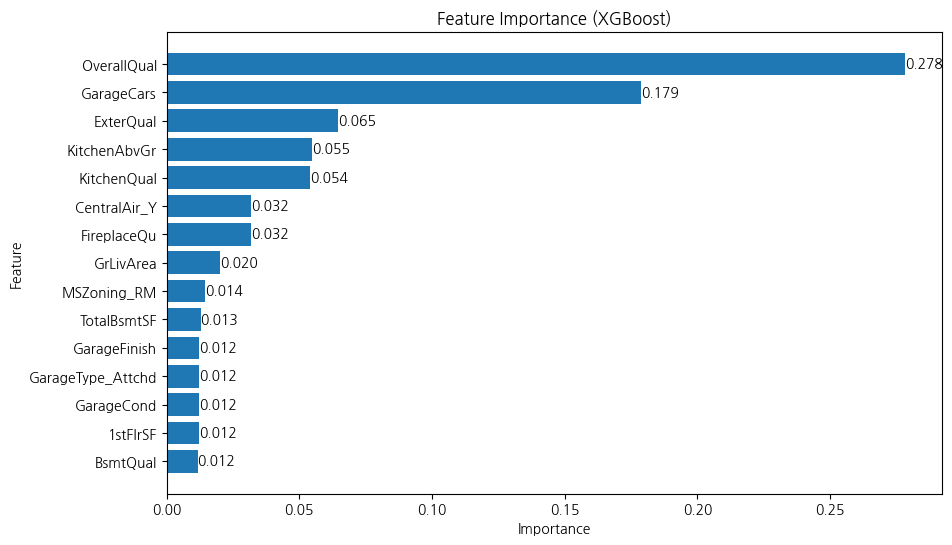

In [12]:
# 중요도 추출
importances = xgb.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# 상위 15개만 보기
top_feat = feat_imp.head(15)

plt.figure(figsize=(10,6))
bars = plt.barh(top_feat.index, top_feat.values)
plt.gca().invert_yaxis()

plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')

# 수치 표시
for i, v in enumerate(top_feat.values):
    plt.text(v, i, f'{v:.3f}', va='center')

plt.show()

In [13]:
result_df = pd.DataFrame(results)

result_df = result_df[
    ['Model', 'MSE', 'RMSE', 'MAE', 'R2(%)', 'NRMSE(%)', 'NMAE(%)']
]

result_df.style.format({
    'MSE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'MAE': '{:,.2f}',
    'R2(%)': '{:.2f}%',
    'NRMSE(%)': '{:.2f}%',
    'NMAE(%)': '{:.2f}%'
})

,Model,MSE,RMSE,MAE,R2(%),NRMSE(%),NMAE(%)
0,Linear Regression,"530,389,555.26","23,030.19","15,053.82",92.02%,12.87%,8.41%
1,Ridge,"412,186,856.74","20,302.39","14,261.51",93.80%,11.34%,7.97%
2,Lasso,"464,895,610.74","21,561.44","14,727.50",93.01%,12.05%,8.23%
3,Random Forest,"841,058,579.25","29,001.01","16,897.63",87.35%,16.20%,9.44%
4,GBM,"554,019,837.73","23,537.63","14,365.46",91.67%,13.15%,8.03%
5,XGBoost,"571,708,697.66","23,910.43","14,907.42",91.40%,13.36%,8.33%
6,LightGBM,"639,190,155.02","25,282.21","14,706.51",90.38%,14.13%,8.22%


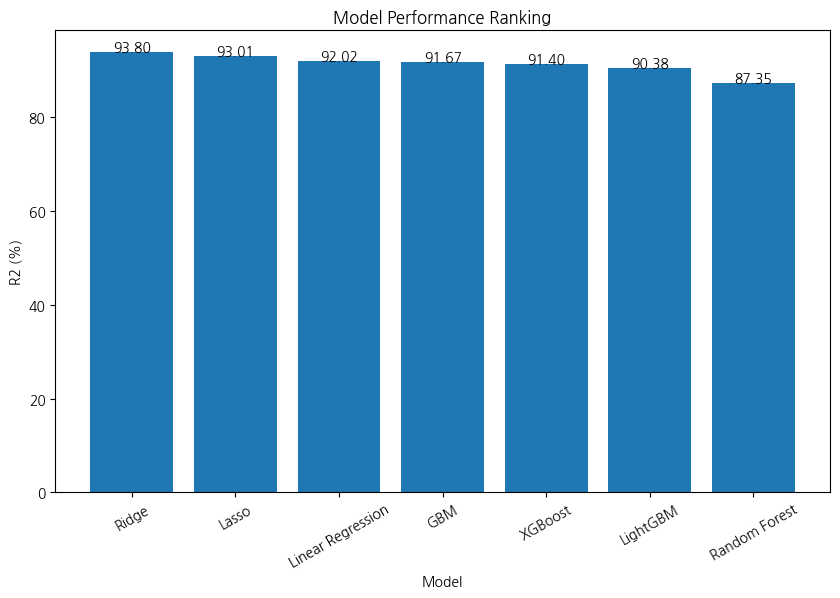

In [16]:
result_df_sorted = result_df.sort_values(by='R2(%)', ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(result_df_sorted['Model'], result_df_sorted['R2(%)'])

for i, v in enumerate(result_df_sorted['R2(%)']):
    plt.text(i, v + 0.2, f"{v:.2f}", ha='center')

plt.xticks(rotation=30)
plt.xlabel('Model')
plt.ylabel('R2 (%)')
plt.title('Model Performance Ranking')
plt.savefig('모델성능비교1.png')

plt.show()